In [1]:
from PIL import Image
import numpy as np

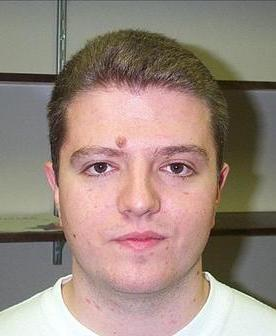

In [2]:
img = Image.open("../Data/Face/Aiden/image_0000.jpg")
img

In [3]:
# 배열 크기 확인
np.array(img).shape

(336, 276, 3)

#### Aiden 이미지 평균 해상도

In [4]:
import glob

In [5]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob("../Data/Face/Aiden/*.jpg")):
   Aiden = np.array(Image.open(file), dtype=np.int32)
   widthRatio.append(Aiden.shape[1]) # w -> 1
   heightRatio.append(Aiden.shape[0]) # h -> 0

In [6]:
print("Aiden 너비 평균 해상도:", np.mean(widthRatio))
print("Aiden 높이 평균 해상도:", np.mean(heightRatio))

print("w : 280, h : 238")


Aiden 너비 평균 해상도: 278.55555555555554
Aiden 높이 평균 해상도: 326.55555555555554
w : 280, h : 238


In [7]:
i = 1
for file in sorted(glob.glob("../Data/Face/Aiden/*.jpg")):
   Aiden = Image.open(file)
   imgResize = Aiden.resize((280,238), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/Face/AidenNew/image_{i:02}.jpg", "JPEG")
   i+=1

In [8]:
i = 1
for file in sorted(glob.glob("../Data/Face/Andrew/*.jpg")):
   Andrew = Image.open(file)
   imgResize = Andrew.resize((280,238), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/Face/AndrewNew/image_{i:02}.jpg", "JPEG")
   i+=1

In [9]:
i = 1
for file in sorted(glob.glob("../Data/Face/Cathy/*.jpg")):
   Cathy = Image.open(file)
   imgResize = Cathy.resize((280,238), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/Face/CathyNew/image_{i:02}.jpg", "JPEG")
   i+=1

In [10]:
number_of_data = 18
img_width_size = 280
img_height_size = 238

In [11]:
AidenData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
AidenData.shape

(18, 238, 280)

In [12]:
i = 0
for file in sorted(glob.glob("../Data/Face/AidenNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   AidenData[i,:,:] = img
   i+=1
AidenData.shape

(18, 238, 280)

In [13]:
print(AidenData[0].shape)

(238, 280)


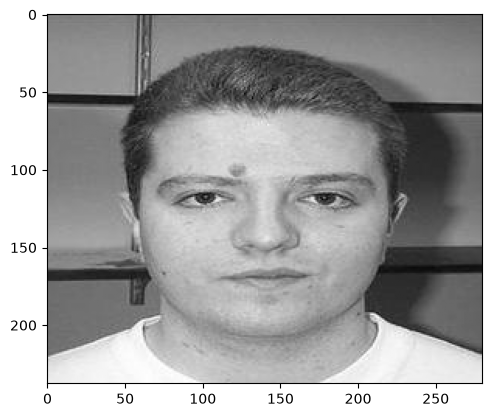

In [14]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(AidenData[0].reshape(238,280), cmap='gray')
plt.show()

In [15]:
AndrewData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
AndrewData.shape

(18, 238, 280)

In [16]:
i = 0
for file in sorted(glob.glob("../Data/Face/AndrewNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   AndrewData[i,:,:] = img
   i+=1
AndrewData.shape

(18, 238, 280)

In [17]:
print(AndrewData[0].shape)

(238, 280)


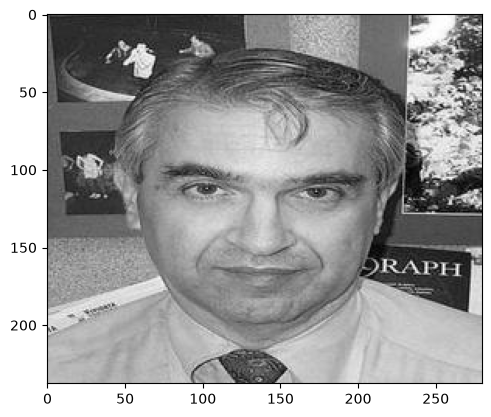

In [18]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(AndrewData[0].reshape(238,280), cmap='gray')
plt.show()

In [19]:
CathyData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
CathyData.shape

(18, 238, 280)

In [20]:
i = 0
for file in sorted(glob.glob("../Data/Face/CathyNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   CathyData[i,:,:] = img
   i+=1
CathyData.shape

(18, 238, 280)

In [21]:
print(CathyData[0].shape)

(238, 280)


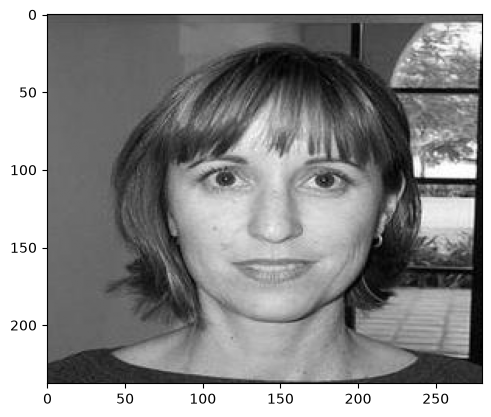

In [22]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(CathyData[0].reshape(238,280), cmap='gray')
plt.show()

In [23]:
train = np.concatenate(
   [AidenData, AndrewData, CathyData]
)
train.shape

(54, 238, 280)

In [24]:
target = np.concatenate(
   [np.zeros(18), np.ones(18), np.full(18, 2)]
)
target.shape

(54,)

In [25]:
# 정규화 및 채널추가
train = train.reshape(-1,img_height_size,img_width_size,1) / 255.0
train.shape

(54, 238, 280, 1)

In [26]:
# Train과 Test 분리
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
   train_test_split(
      train,
      target,
      test_size=0.2,
      random_state=42
   )

In [27]:
# CNN 만들기
from tensorflow import keras
from tensorflow.keras.layers import Input

model = keras.Sequential()
model.add(
   Input(shape=(img_height_size, img_width_size, 1))
)

model.add(
   keras.layers.Conv2D(
      32,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)
model.add(keras.layers.MaxPool2D(2))

model.add(
   keras.layers.Conv2D(
      64,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)
model.add(keras.layers.MaxPool2D(2))

2026-07-09 18:19:36.706314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [28]:
model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(100, activation='relu'))

# model.add(keras.layers.Dropout(0.3))

# 출력층: 클래스가 3개니까 Dense(3) + softmax
model.add(
   keras.layers.Dense(3, activation='softmax')
)

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 238, 280, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 119, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 119, 140, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 59, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 264320)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    26,432,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,451,219 (100.90 MB)

 Trainable params: 26,451,219 (100.90 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
   loss='sparse_categorical_crossentropy',  # 다중분류(3개 클래스)라서 이걸로
   optimizer='adam',
   metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    "../Data/best_cnn_face.keras",
    save_best_only=True
)
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True
)

In [31]:
train_scaled, val_scaled, train_target, val_target = \
   train_test_split(
      train_data,
      train_target,
      test_size=0.2,
      random_state=42
   )

print(train_scaled.shape, val_scaled.shape)

(34, 238, 280, 1) (9, 238, 280, 1)


In [32]:
history = model.fit(
   train_scaled,
   train_target,
   epochs=50,
   validation_data=(val_scaled, val_target),
   callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.2353 - loss: 1.7964 - val_accuracy: 0.0000e+00 - val_loss: 5.6687
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.4118 - loss: 3.1021 - val_accuracy: 0.5556 - val_loss: 1.1973
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2647 - loss: 1.3361 - val_accuracy: 0.4444 - val_loss: 1.0373
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 502ms/step - accuracy: 0.7059 - loss: 0.7678 - val_accuracy: 0.1111 - val_loss: 1.7247
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 662ms/step - accuracy: 0.7059 - loss: 0.7506 - val_accuracy: 0.4444 - val_loss: 1.3738
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.7647 - loss: 0.6414 - val_accuracy: 0.5556 - val_loss: 0.7516
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.8824 - loss: 0.3517 - val_accuracy: 0.1111 - val_loss: 1.3544
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 583ms/step - accuracy: 0.6765 - loss: 0.4823 - val_accuracy: 0.4444 - val_loss: 0.8049


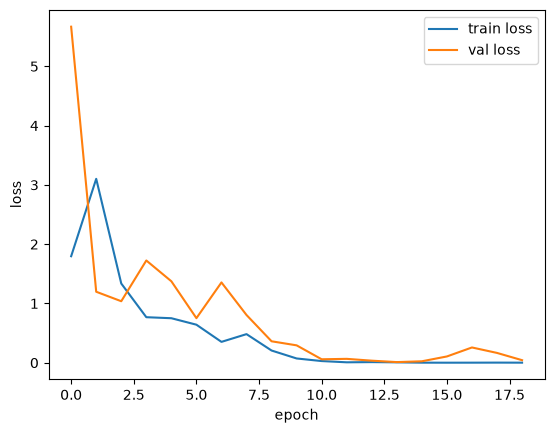

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()



In [34]:
train_loss, train_acc = model.evaluate(train_scaled, train_target)
test_loss, test_acc = model.evaluate(test_data, test_target)

print(f"Train 정확도: {train_acc:.4f}")
print(f"Test 정확도: {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 131ms/step - accuracy: 1.0000 - loss: 9.6488e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9091 - loss: 0.3415
Train 정확도: 1.0000
Test 정확도: 0.9091
